# Рубежный контроль №1 (вариант 1)

Выполнил: студент группы РТ5-61Б, Бляблин Е.А.

Номер задачи: 1

Номер набора данных: 1

## Датасет

Ирисы из SKLearn (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris)

## Задача

Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

## Дополнительные требования

Для пары произвольных колонок данных построить график "Jointplot".

**Вместо библиотеки pandas используется polars по причине большей выразительности синтаксиса (и личных предпочтений).**

In [1]:
from sklearn.datasets import load_iris
import polars as pl


iris = load_iris()

data = pl.DataFrame(
    iris["data"],
    schema=iris["feature_names"],
).with_columns(target=pl.Series(iris["target"]))
data

sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
f64,f64,f64,f64,i64
5.1,3.5,1.4,0.2,0
4.9,3.0,1.4,0.2,0
4.7,3.2,1.3,0.2,0
4.6,3.1,1.5,0.2,0
5.0,3.6,1.4,0.2,0
…,…,…,…,…
6.7,3.0,5.2,2.3,2
6.3,2.5,5.0,1.9,2
6.5,3.0,5.2,2.0,2


Датасет состоит из 150 строк и 5 колонок. Колонки 0-3 - числовые, колонка 4 - категориальная.

In [2]:
data.describe()

statistic,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
str,f64,f64,f64,f64,f64
"""count""",150.0,150.0,150.0,150.0,150.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",5.843333,3.057333,3.758,1.199333,1.0
"""std""",0.828066,0.435866,1.765298,0.762238,0.819232
"""min""",4.3,2.0,1.0,0.1,0.0
"""25%""",5.1,2.8,1.6,0.3,0.0
"""50%""",5.8,3.0,4.4,1.3,1.0
"""75%""",6.4,3.3,5.1,1.8,2.0
"""max""",7.9,4.4,6.9,2.5,2.0


В датасете нет пропусков.

Построим корреляционную матрицу для всех числовых колонок.

In [3]:
corr_matrix = data.corr().with_columns(pl.all().round(4))
corr_matrix

sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
f64,f64,f64,f64,f64
1.0,-0.1176,0.8718,0.8179,0.7826
-0.1176,1.0,-0.4284,-0.3661,-0.4267
0.8718,-0.4284,1.0,0.9629,0.949
0.8179,-0.3661,0.9629,1.0,0.9565
0.7826,-0.4267,0.949,0.9565,1.0


Построим тепловую карту для корреляционной матрицы.

<Axes: >

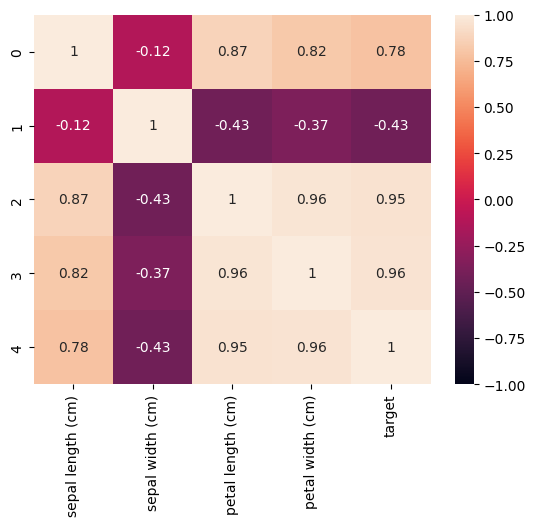

In [4]:
import seaborn as sns

sns.heatmap(corr_matrix.to_pandas(), annot=True, vmin=-1, vmax=1)

## По корреляционной матрице можно сделать следующие выводы:

- Между видом ириса и всеми признаками имеется корреляция. Все признаки кроме ширины чашелистика (`sepal width (cm)`) очень сильны (0,78 и выше), но ширина чашелистика также имеет умеренную корреляцию (-0,43).
- Признаки `sepal length (cm)`, `petal width (cm)` и `petal length (cm)` имеют высокую корреляцию между собой, что может негативно сказаться на модели, так как эти признаки могут вносить избыточную информацию. В случае использования линейных моделей стоит рассмотреть вариант оставить только один из этих признаков, желательно `petal length (cm)` или `petal width (cm)`, так как они имеют более высокую корреляцию с целевым признаком.


## Дополнительный график

Построим график "Jointplot" для признаков `petal length (cm)` и `petal width (cm)`.

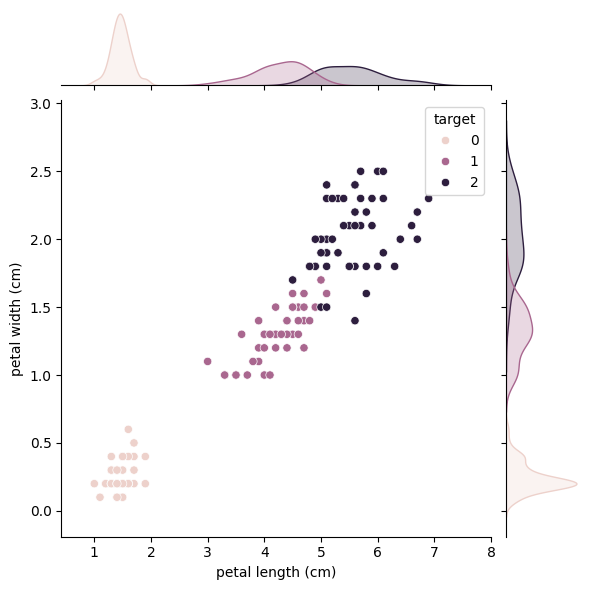

In [5]:
sns.jointplot(data=data.to_pandas(), x="petal length (cm)", y="petal width (cm)", hue="target", kind="scatter")